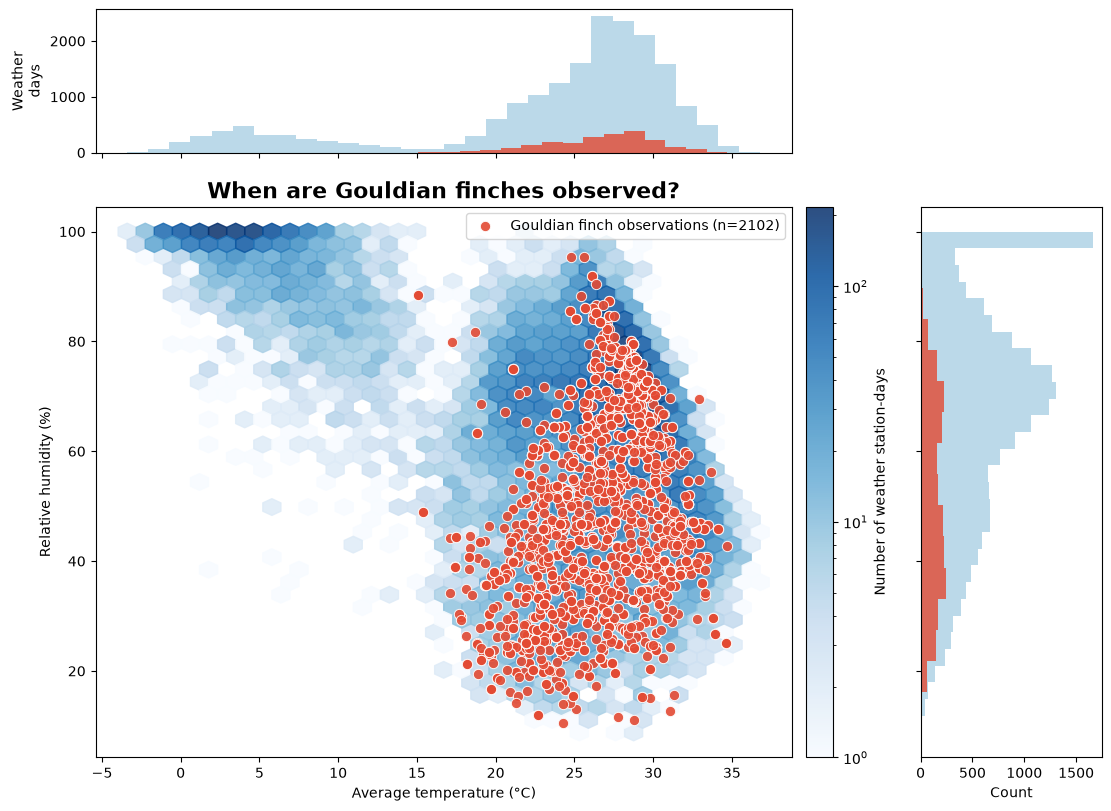

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

base_url = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2026/2026-07-28"

occurrences = pd.read_csv(f"{base_url}/occurrences.csv", parse_dates=["date"])
weather = pd.read_csv(f"{base_url}/weather.csv", parse_dates=["date"])

# Match each observation to weather at the nearest station on that date
finch_weather = (
    occurrences.loc[
        occurrences["organism_name"].eq("Gouldian finch"),
        ["date", "ws_id"]
    ]
    .merge(weather, on=["date", "ws_id"], how="inner")
    .dropna(subset=["temp", "rh"])
)

weather_plot = weather.dropna(subset=["temp", "rh"])

fig = plt.figure(figsize=(11, 8), constrained_layout=True)
grid = fig.add_gridspec(
    2, 2, width_ratios=(5, 1.3), height_ratios=(1.3, 5),
    wspace=0.05, hspace=0.05
)

ax = fig.add_subplot(grid[1, 0])
ax_top = fig.add_subplot(grid[0, 0], sharex=ax)
ax_right = fig.add_subplot(grid[1, 1], sharey=ax)

# All available weather conditions
hb = ax.hexbin(
    weather_plot["temp"],
    weather_plot["rh"],
    gridsize=35,
    mincnt=1,
    cmap="Blues",
    norm=LogNorm(),
    alpha=0.85
)

# Conditions during Gouldian finch observations
ax.scatter(
    finch_weather["temp"],
    finch_weather["rh"],
    s=55,
    color="#e34a33",
    edgecolor="white",
    linewidth=0.7,
    alpha=0.9,
    label=f"Gouldian finch observations (n={len(finch_weather)})"
)

# Marginal distributions
ax_top.hist(weather_plot["temp"], bins=30, color="#9ecae1", alpha=0.7)
ax_top.hist(finch_weather["temp"], bins=15, color="#e34a33", alpha=0.8)
ax_top.tick_params(axis="x", labelbottom=False)
ax_top.set_ylabel("Weather\ndays")

ax_right.hist(
    weather_plot["rh"], bins=30, orientation="horizontal",
    color="#9ecae1", alpha=0.7
)
ax_right.hist(
    finch_weather["rh"], bins=15, orientation="horizontal",
    color="#e34a33", alpha=0.8
)
ax_right.tick_params(axis="y", labelleft=False)
ax_right.set_xlabel("Count")

ax.set_xlabel("Average temperature (°C)")
ax.set_ylabel("Relative humidity (%)")
ax.set_title("When are Gouldian finches observed?", fontsize=16, weight="bold")
ax.legend(frameon=True)

cbar = fig.colorbar(hb, ax=ax, pad=0.02)
cbar.set_label("Number of weather station-days")

plt.show()